In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/happyparsi/pharma-1/sample_submission.csv
/kaggle/input/datasets/happyparsi/pharma-1/train.csv
/kaggle/input/datasets/happyparsi/pharma-1/test.csv


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


 **Loading Dataset**

In [4]:
train_df=pd.read_csv('/kaggle/input/datasets/happyparsi/pharma-1/train.csv')
test_df=pd.read_csv('/kaggle/input/datasets/happyparsi/pharma-1/test.csv')

#  dataset description

In [27]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient Age,20656.0,6.974148,4.319475,0.000000,3.000000,7.000000,11.000000,14.000000
Blood cell count (mcL),22083.0,4.898871,0.199663,4.092727,4.763109,4.899399,5.033830,5.609829
Mother's age,16047.0,34.526454,9.852598,18.000000,26.000000,35.000000,43.000000,51.000000
Father's age,16097.0,41.972852,13.035501,20.000000,31.000000,42.000000,53.000000,64.000000
Test 1,19956.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Test 2,19931.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Test 3,19936.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Test 4,19943.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Test 5,19913.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
No. of previous abortion,19921.0,2.003062,1.411919,0.000000,1.000000,2.000000,3.000000,4.000000


In [26]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient Age,9465.0,7.041838,4.337995,0.000000,3.000000,7.000000,11.000000,14.000000
Blood cell count (mcL),9465.0,4.900207,0.199159,4.120469,4.765843,4.898950,5.033164,5.676184
Mother's age,9465.0,34.575489,9.834870,18.000000,26.000000,35.000000,43.000000,51.000000
Father's age,9465.0,41.830745,13.040945,20.000000,30.000000,42.000000,53.000000,64.000000
Test 1,9465.0,-22.174326,41.276356,-99.000000,0.000000,0.000000,0.000000,0.000000
Test 2,9465.0,-21.766403,41.003356,-99.000000,0.000000,0.000000,0.000000,0.000000
Test 3,9465.0,-21.954675,41.130084,-99.000000,0.000000,0.000000,0.000000,0.000000
Test 4,9465.0,-20.996830,41.424676,-99.000000,1.000000,1.000000,1.000000,1.000000
Test 5,9465.0,-21.870998,41.073915,-99.000000,0.000000,0.000000,0.000000,0.000000
No. of previous abortion,9465.0,-20.352879,41.965045,-99.000000,0.000000,1.000000,3.000000,4.000000


In [11]:
train_df.head()


,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


In [12]:
test_df.head()

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,PID0x4175,6,No,Yes,No,No,4.981655,Charles,NaN,Kore,...,-99,2,Multiple,-99.000000,slightly abnormal,True,True,True,True,True
1,PID0x21f5,10,Yes,No,NaN,Yes,5.118890,Catherine,NaN,Homero,...,Yes,-99,Multiple,8.179584,normal,False,False,False,True,False
2,PID0x49b8,5,No,NaN,No,No,4.876204,James,NaN,Danield,...,No,0,Singular,-99.000000,slightly abnormal,False,False,True,True,False
3,PID0x2d97,13,No,Yes,Yes,No,4.687767,Brian,NaN,Orville,...,Yes,-99,Singular,6.884071,normal,True,False,True,False,True
4,PID0x58da,5,No,NaN,NaN,Yes,5.152362,Gary,NaN,Issiah,...,No,-99,Multiple,6.195178,normal,True,True,True,True,False


In [39]:
print("train:",train_df.columns.tolist())
print("\n\ntest:",test_df.columns.tolist())

train ['Patient Id', 'Patient Age', "Genes in mother's side", 'Inherited from father', 'Maternal gene', 'Paternal gene', 'Blood cell count (mcL)', 'Patient First Name', 'Family Name', "Father's name", "Mother's age", "Father's age", 'Institute Name', 'Location of Institute', 'Status', 'Respiratory Rate (breaths/min)', 'Heart Rate (rates/min', 'Test 1', 'Test 2', 'Test 3', 'Test 4', 'Test 5', 'Parental consent', 'Follow-up', 'Gender', 'Birth asphyxia', 'Autopsy shows birth defect (if applicable)', 'Place of birth', 'Folic acid details (peri-conceptional)', 'H/O serious maternal illness', 'H/O radiation exposure (x-ray)', 'H/O substance abuse', 'Assisted conception IVF/ART', 'History of anomalies in previous pregnancies', 'No. of previous abortion', 'Birth defects', 'White Blood cell count (thousand per microliter)', 'Blood test result', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5', 'Genetic Disorder', 'Disorder Subclass']


test ['Patient Id', 'Patient Age', "Genes in

In [19]:
print(train_df.shape)
print(test_df.nunique())#number of unique entries in our dataset
train_df.info()


(22083, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22083 entries, 0 to 22082
Data columns (total 45 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Patient Id                                        22083 non-null  object 
 1   Patient Age                                       20656 non-null  float64
 2   Genes in mother's side                            22083 non-null  object 
 3   Inherited from father                             21777 non-null  object 
 4   Maternal gene                                     19273 non-null  object 
 5   Paternal gene                                     22083 non-null  object 
 6   Blood cell count (mcL)                            22083 non-null  float64
 7   Patient First Name                                22083 non-null  object 
 8   Family Name                                       12392 non-null  object 
 9   Fathe

In [22]:
print(test_df.shape)
print(test_df.nunique()) #number of unique entries in our dataset
test_df.info()

(9465, 43)
Patient Id                                          9465
Patient Age                                           15
Genes in mother's side                                 2
Inherited from father                                  2
Maternal gene                                          2
Paternal gene                                          2
Blood cell count (mcL)                              9465
Patient First Name                                  1688
Family Name                                          141
Father's name                                       8301
Mother's age                                          34
Father's age                                          45
Institute Name                                        28
Location of Institute                                 26
Status                                                 2
Respiratory Rate (breaths/min)                         3
Heart Rate (rates/min                                  3
Test 1              

# Checking for null values

In [31]:
train_df.isnull().sum()

Patient Id                                             0
Patient Age                                         1427
Genes in mother's side                                 0
Inherited from father                                306
Maternal gene                                       2810
Paternal gene                                          0
Blood cell count (mcL)                                 0
Patient First Name                                     0
Family Name                                         9691
Father's name                                          0
Mother's age                                        6036
Father's age                                        5986
Institute Name                                      5106
Location of Institute                                  0
Status                                                 0
Respiratory Rate (breaths/min)                      2149
Heart Rate (rates/min                               2113
Test 1                         

In [32]:
test_df.isnull().sum()

Patient Id                                             0
Patient Age                                            0
Genes in mother's side                                 0
Inherited from father                                551
Maternal gene                                       3723
Paternal gene                                          0
Blood cell count (mcL)                                 0
Patient First Name                                     0
Family Name                                         9317
Father's name                                          0
Mother's age                                           0
Father's age                                           0
Institute Name                                      2036
Location of Institute                                  0
Status                                                 0
Respiratory Rate (breaths/min)                      2886
Heart Rate (rates/min                               2900
Test 1                         

# Checking for duplicated values

In [37]:
print("train:",train_df.duplicated().sum())
print("test:",test_df.duplicated().sum())

train: 0
test: 0


# Encoding columns for visualizations

In [49]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        train_df.loc[:, col] = le.fit_transform(train_df[col])

In [58]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in test_df.columns:
    if test_df[col].dtype == 'object':
        test_df.loc[:, col] = le.fit_transform(test_df[col])

In [50]:
train_df.head()

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,12659,2.0,1,0,1,0,4.760603,2008,6282,9538,...,2,9.857562,4,1.0,1.0,1.0,1.0,1.0,0,5
1,3249,4.0,1,1,0,0,4.910669,1742,6282,2030,...,0,5.522560,2,1.0,NaN,1.0,1.0,0.0,3,2
2,8730,6.0,1,0,0,0,4.893297,1348,6282,11156,...,1,NaN,2,0.0,1.0,1.0,1.0,1.0,1,3
3,8764,12.0,1,0,1,0,4.705280,1153,2580,62,...,1,7.919321,1,0.0,0.0,1.0,0.0,0.0,0,6
4,1781,11.0,1,0,2,1,4.720703,1208,5532,14014,...,0,4.098210,4,0.0,0.0,0.0,0.0,NaN,1,1


In [59]:
test_df.head()

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,3242,6,0,1,0,0,4.981655,270,141,4622,...,0,2,1,-99.000000,4,True,True,True,True,True
1,1213,10,1,0,2,1,5.118890,250,141,3067,...,2,-99,1,8.179584,3,False,False,False,True,False
2,3802,5,0,2,0,0,4.876204,721,141,1649,...,1,0,2,-99.000000,4,False,False,True,True,False
3,1954,13,0,1,1,0,4.687767,196,141,5955,...,2,-99,2,6.884071,3,True,False,True,False,True
4,4770,5,0,2,2,1,5.152362,582,141,3207,...,1,-99,1,6.195178,3,True,True,True,True,False


# Multivariate Analysis

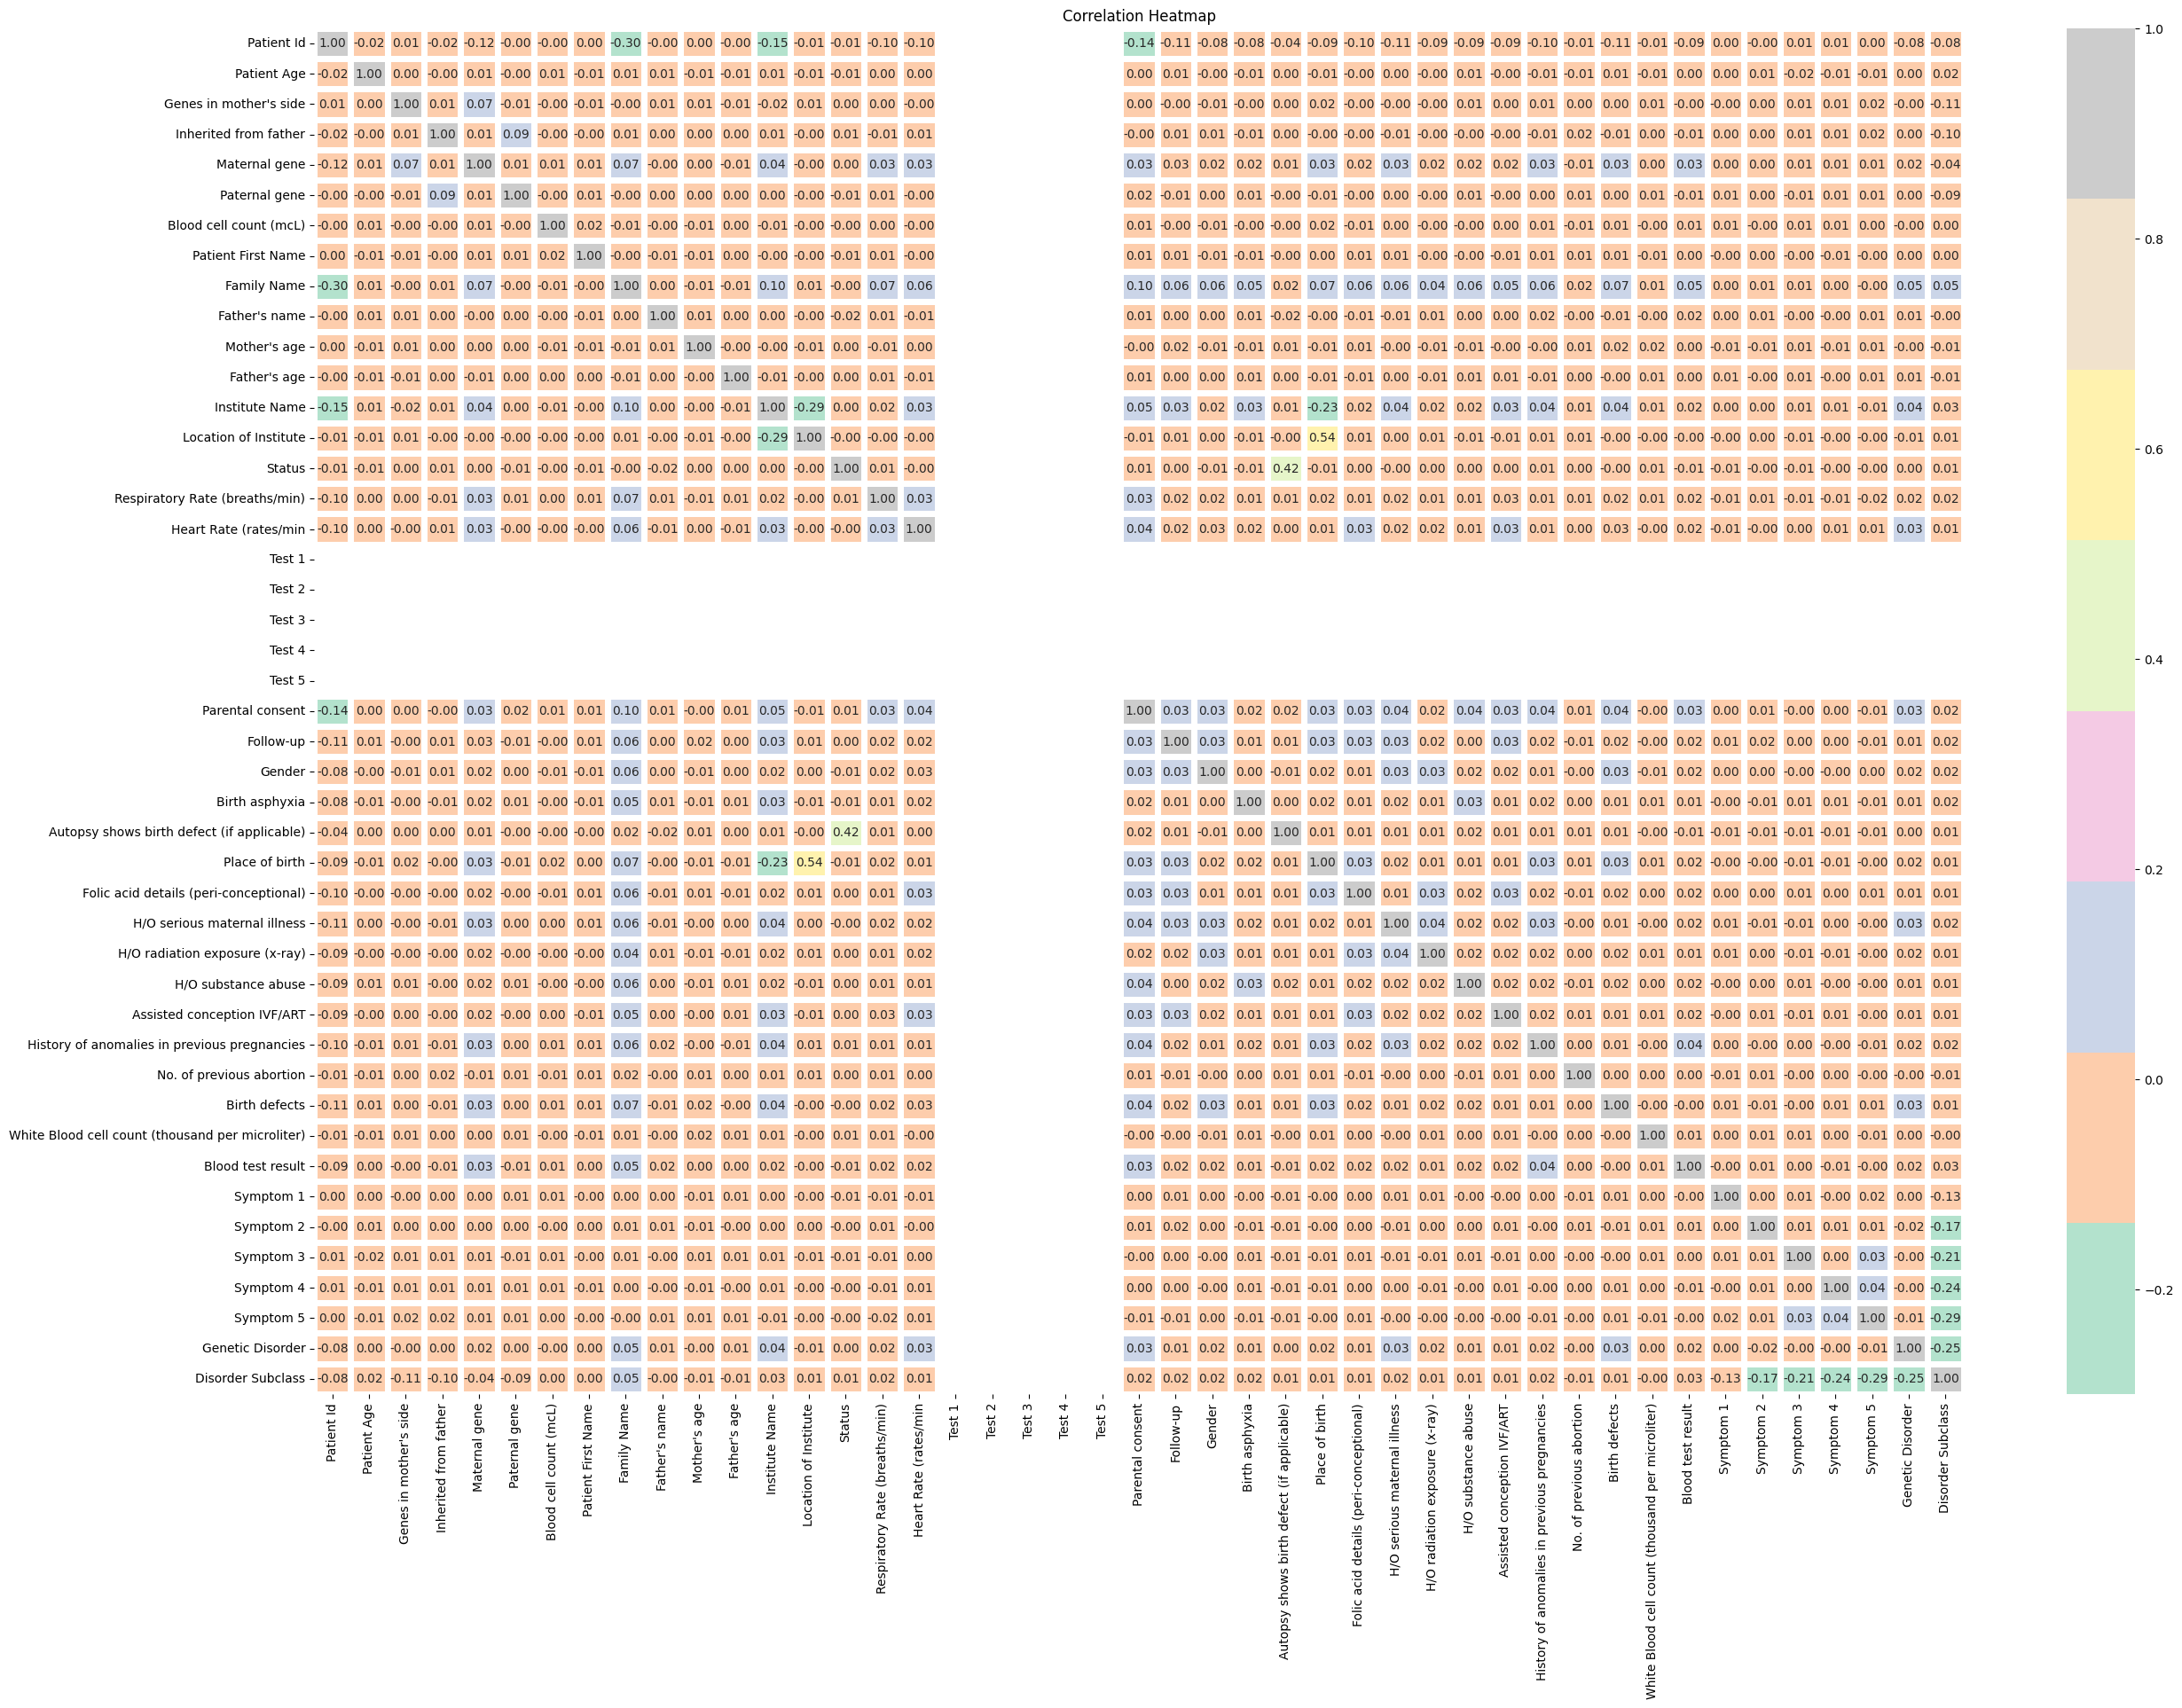

In [57]:
plt.figure(figsize=(30, 20))

sns.heatmap(train_df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=5)

plt.title('Correlation Heatmap')
plt.show()

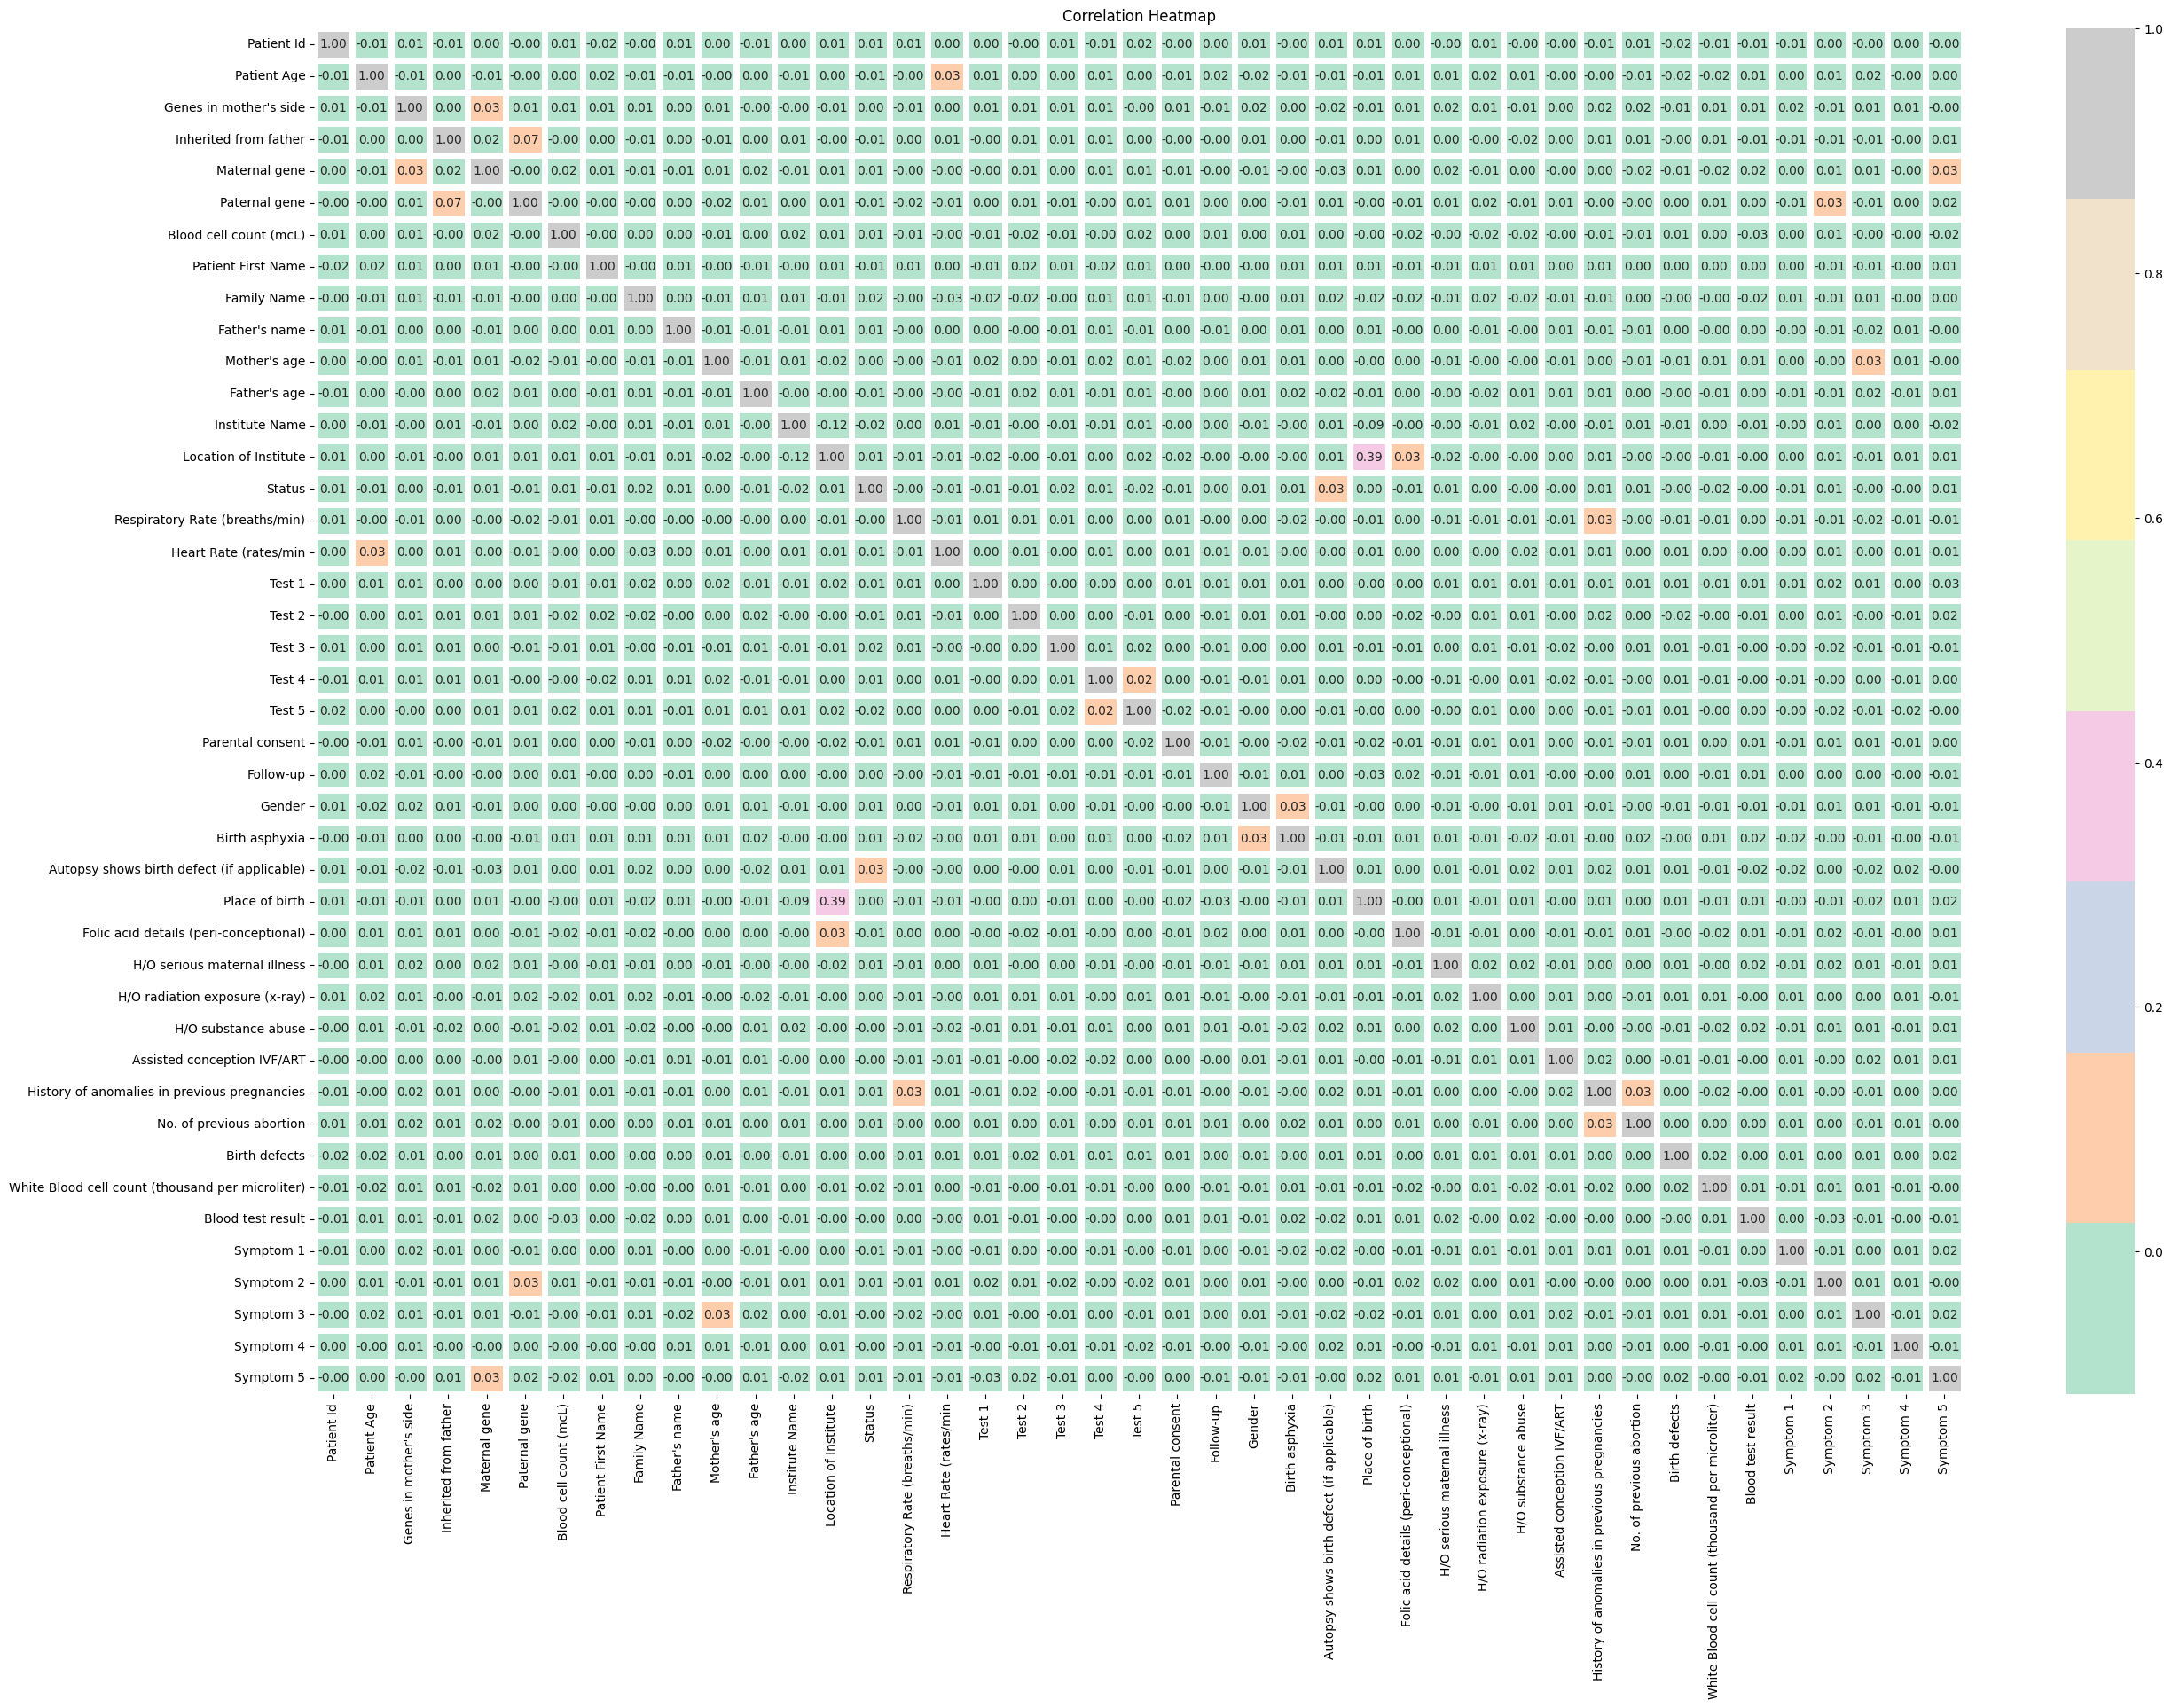

In [60]:
plt.figure(figsize=(30, 20))

sns.heatmap(test_df.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=5)

plt.title('Correlation Heatmap')
plt.show()

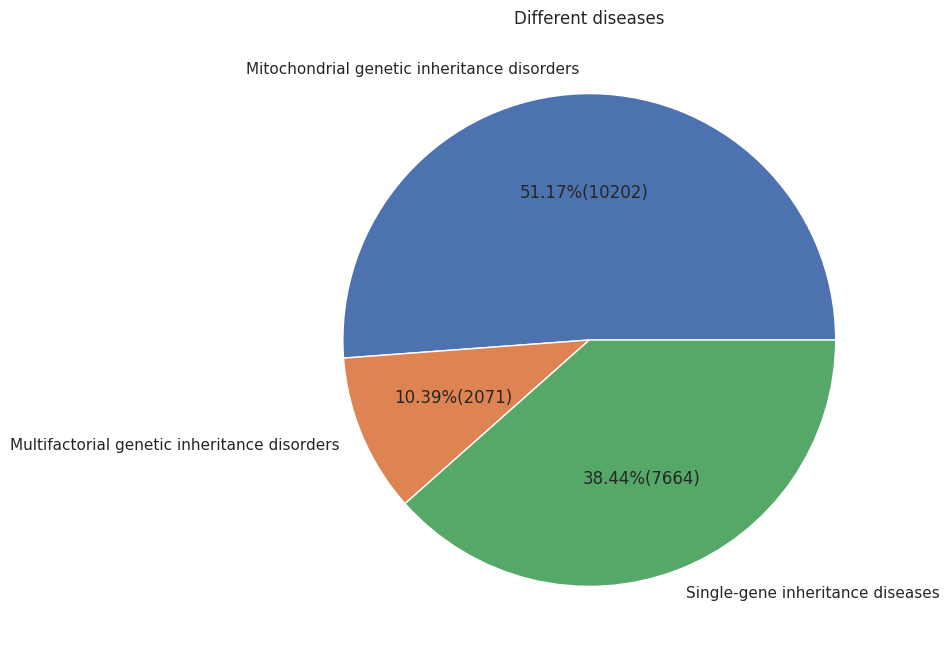

In [65]:
path = r"/kaggle/input/datasets/happyparsi/pharma-1/train.csv"

train_df = pd.read_csv(path, engine='python', encoding='utf_8_sig')

Gene= train_df.groupby('Genetic Disorder').size()

sns.set()
Gene.plot(kind='pie', title='Different diseases', figsize=[8,8],
          autopct=lambda p: '{:.2f}%({:.0f})'.format(p,(p/100)*Gene.sum()))
plt.show()


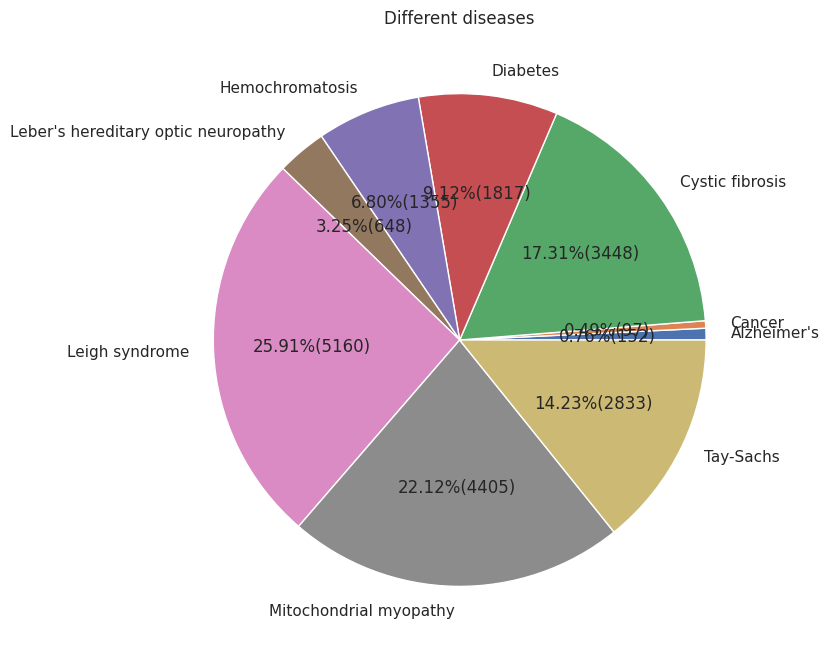

In [80]:
path = r"/kaggle/input/datasets/happyparsi/pharma-1/train.csv"

train_df = pd.read_csv(path, engine='python', encoding='utf_8_sig')

Disorder= train_df.groupby('Disorder Subclass').size()

sns.set()
Disorder.plot(kind='pie', title='Different diseases', figsize=[8,8],
          autopct=lambda p: '{:.2f}%({:.0f})'.format(p,(p/100)*Disorder.sum()))
plt.show()


<Axes: xlabel='Patient Age', ylabel='Count'>

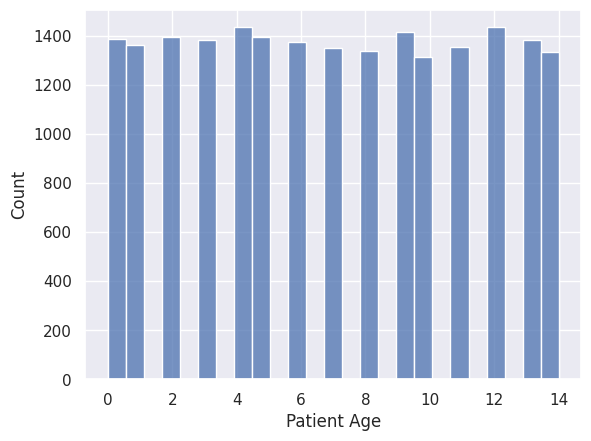

In [79]:
sns.histplot(train_df['Patient Age'])